# Global Air Freight Analysis: Trends, Leaders and Growth Patterns (2005–2019)

**Author:** Muhammad Umer Mehmood

**Education:** Master's In Data Science

---

**Overview of the Dataset Background**

One of the most reliable open data sources in the world, the World Bank's World Development Indicators (WDI), is the source of this dataset. From 2005 to 2019, it monitored air travel activity in 230 countries using four primary metrics: air freight, people carried, carrier departures, and logistics infrastructure quality (LPI score).

**Motivation:**

The core motivation behind analyzing this dataset is to answer real business questions:

Which countries are the biggest players in global air freight?
How has air transport grown over 15 years (2005–2019)?
Does better logistics infrastructure lead to more freight volume?
Which regions are underperforming relative to their potential?
How did the pre-COVID era shape the air cargo industry?

**Data Source:** [World Bank Air Transport](https://www.kaggle.com/datasets/tjkyner/global-air-transport-data)

## Import Dataset

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/umercheena/air-cargo-1/data.csv")

In [2]:
df.head()

,Series Name,Series Code,Country Name,Country Code,2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
0,"Air transport, registered carrier departures w...",IS.AIR.DPRT,Afghanistan,AFG,..,..,..,..,..,21677,25021,17775,21696,25920,23532,22770,24207,10454,7334,..
1,"Air transport, registered carrier departures w...",IS.AIR.DPRT,Albania,ALB,4309,4481,4930,5058,5140,9412,10373.2109418273,10309.1791376912,11196,1992,..,306,1904,2935,2558,..
2,"Air transport, registered carrier departures w...",IS.AIR.DPRT,Algeria,DZA,45692,44822,44136,31026,52731,53088,53286,54292,55516,60066,65940,73465,74714,77463,76001,..
3,"Air transport, registered carrier departures w...",IS.AIR.DPRT,American Samoa,ASM,..,..,..,..,..,3420.57075456399,3577.61386138614,3963.0036477332,8580,9144,..,..,..,..,..,..
4,"Air transport, registered carrier departures w...",IS.AIR.DPRT,Andorra,AND,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..


In [3]:
df.tail()

,Series Name,Series Code,Country Name,Country Code,2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
1056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1059,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1060,Last Updated: 05/25/2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns.tolist()
df.dtypes

Series Name      object
Series Code      object
Country Name     object
Country Code     object
2005 [YR2005]    object
2006 [YR2006]    object
2007 [YR2007]    object
2008 [YR2008]    object
2009 [YR2009]    object
2010 [YR2010]    object
2011 [YR2011]    object
2012 [YR2012]    object
2013 [YR2013]    object
2014 [YR2014]    object
2015 [YR2015]    object
2016 [YR2016]    object
2017 [YR2017]    object
2018 [YR2018]    object
2019 [YR2019]    object
2020 [YR2020]    object
dtype: object

In [5]:
print(df.isnull().sum())

Series Name      3
Series Code      5
Country Name     5
Country Code     5
2005 [YR2005]    5
2006 [YR2006]    5
2007 [YR2007]    5
2008 [YR2008]    5
2009 [YR2009]    5
2010 [YR2010]    5
2011 [YR2011]    5
2012 [YR2012]    5
2013 [YR2013]    5
2014 [YR2014]    5
2015 [YR2015]    5
2016 [YR2016]    5
2017 [YR2017]    5
2018 [YR2018]    5
2019 [YR2019]    5
2020 [YR2020]    5
dtype: int64


In [6]:
valid_codes = ['IS.AIR.DPRT', 'IS.AIR.GOOD.MT.K1', 'IS.AIR.PSGR', 'LP.LPI.INFR.XQ']
df = df[df['Series Code'].isin(valid_codes)].copy()
print(df.shape)

(1056, 20)


In [7]:
df.rename(columns={
    'Series Name'  : 'series_name',
    'Series Code'  : 'series_code',
    'Country Name' : 'country',
    'Country Code' : 'country_code'
}, inplace=True)

print(df.columns.tolist())

['series_name', 'series_code', 'country', 'country_code', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]']


In [8]:
import numpy as np

year_cols = [c for c in df.columns if 'YR' in c]
df[year_cols] = df[year_cols].replace('..', np.nan)
print(df.isnull().sum())

series_name         0
series_code         0
country             0
country_code        0
2005 [YR2005]     518
2006 [YR2006]     521
2007 [YR2007]     332
2008 [YR2008]     524
2009 [YR2009]     510
2010 [YR2010]     241
2011 [YR2011]     441
2012 [YR2012]     242
2013 [YR2013]     444
2014 [YR2014]     253
2015 [YR2015]     472
2016 [YR2016]     266
2017 [YR2017]     476
2018 [YR2018]     241
2019 [YR2019]     454
2020 [YR2020]    1056
dtype: int64


/tmp/ipykernel_55/2063067642.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[year_cols] = df[year_cols].replace('..', np.nan)


In [9]:
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')
print(df.dtypes)

series_name       object
series_code       object
country           object
country_code      object
2005 [YR2005]    float64
2006 [YR2006]    float64
2007 [YR2007]    float64
2008 [YR2008]    float64
2009 [YR2009]    float64
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
dtype: object


In [10]:
df_long = df.melt(
    id_vars=['country', 'country_code', 'series_name', 'series_code'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)
print(df_long.shape)
print(df_long.head())

(16896, 6)
          country country_code  \
0     Afghanistan          AFG   
1         Albania          ALB   
2         Algeria          DZA   
3  American Samoa          ASM   
4         Andorra          AND   

                                         series_name  series_code  \
0  Air transport, registered carrier departures w...  IS.AIR.DPRT   
1  Air transport, registered carrier departures w...  IS.AIR.DPRT   
2  Air transport, registered carrier departures w...  IS.AIR.DPRT   
3  Air transport, registered carrier departures w...  IS.AIR.DPRT   
4  Air transport, registered carrier departures w...  IS.AIR.DPRT   

            year    value  
0  2005 [YR2005]      NaN  
1  2005 [YR2005]   4309.0  
2  2005 [YR2005]  45692.0  
3  2005 [YR2005]      NaN  
4  2005 [YR2005]      NaN  


In [11]:
df_long['year'] = df_long['year'].str[:4].astype(int)
print(df_long['year'].unique())

[2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2020]


In [12]:
df_pivot = df_long.pivot_table(
    index=['country', 'country_code', 'year'],
    columns='series_code',
    values='value'
).reset_index()

print(df_pivot.shape)
print(df_pivot.head())

(3061, 7)
series_code      country country_code  year  IS.AIR.DPRT  IS.AIR.GOOD.MT.K1  \
0            Afghanistan          AFG  2007          NaN                NaN   
1            Afghanistan          AFG  2010      21677.0         108.019487   
2            Afghanistan          AFG  2011      25021.0         109.421117   
3            Afghanistan          AFG  2012      17775.0         116.660723   
4            Afghanistan          AFG  2013      21696.0          84.621216   

series_code   IS.AIR.PSGR  LP.LPI.INFR.XQ  
0                     NaN            1.10  
1            1.999127e+06            1.87  
2            2.279341e+06             NaN  
3            1.737962e+06            2.00  
4            2.044188e+06             NaN  


In [13]:
df_pivot.rename(columns={
    'IS.AIR.DPRT'      : 'departures',
    'IS.AIR.GOOD.MT.K1': 'freight_mton_km',
    'IS.AIR.PSGR'      : 'passengers',
    'LP.LPI.INFR.XQ'   : 'lpi_infra_score'
}, inplace=True)

print(df_pivot.columns.tolist())

['country', 'country_code', 'year', 'departures', 'freight_mton_km', 'passengers', 'lpi_infra_score']


In [14]:
df_pivot.to_csv("air_cargo_clean.csv", index=False)
print("Done! Shape:", df_pivot.shape)

Done! Shape: (3061, 7)


## Exploratory Data Analysis (EDA)

In [15]:
import pandas as pd

df = pd.read_csv("air_cargo_clean.csv")

print(df.shape)
print(df.info())
print(df.describe())

(3061, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3061 entries, 0 to 3060
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          3061 non-null   object 
 1   country_code     3061 non-null   object 
 2   year             3061 non-null   int64  
 3   departures       2921 non-null   float64
 4   freight_mton_km  2851 non-null   float64
 5   passengers       2924 non-null   float64
 6   lpi_infra_score  1209 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 167.5+ KB
None
              year    departures  freight_mton_km    passengers  \
count  3061.000000  2.921000e+03      2851.000000  2.924000e+03   
mean   2012.188174  1.271388e+06      7044.619944  1.263117e+08   
std       4.265595  3.855138e+06     22383.815138  3.847931e+08   
min    2005.000000  0.000000e+00         0.000000  0.000000e+00   
25%    2009.000000  1.187400e+04         3.587026  6.430782e+05   

In [16]:
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

country               0
country_code          0
year                  0
departures          140
freight_mton_km     210
passengers          137
lpi_infra_score    1852
dtype: int64
country             0.000000
country_code        0.000000
year                0.000000
departures          4.573669
freight_mton_km     6.860503
passengers          4.475662
lpi_infra_score    60.503104
dtype: float64


In [17]:
exclude = ['World', 'High income', 'Low & middle income', 'OECD members',
           'East Asia & Pacific', 'Europe & Central Asia', 'North America',
           'Post-demographic dividend', 'Late-demographic dividend', 'IDA & IBRD total']

df_countries = df[~df['country'].isin(exclude)]

top10 = df_countries.groupby('country')['freight_mton_km'].sum().sort_values(ascending=False).head(10)
print(top10)

country
United States                                  589293.067256
IBRD only                                      587461.365078
Middle income                                  575810.416564
Upper middle income                            509455.140330
European Union                                 443473.726534
Euro area                                      440983.975140
East Asia & Pacific (IDA & IBRD countries)     343638.386639
East Asia & Pacific (excluding high income)    343582.408599
Middle East & North Africa                     315639.038073
Arab World                                     300392.935515
Name: freight_mton_km, dtype: float64


In [18]:
exclude_codes = ['ARB','CSS','CEB','EAR','EAS','TEA','EAP','ECA','TEC','ECS',
                 'EMU','EUU','FCS','HIC','HPC','IBD','IBT','IDB','IDX','IDA',
                 'LTE','LCN','TLA','LAC','LDC','LMY','LIC','LMC','MEA','TMN',
                 'MNA','MIC','NAC','OED','OSS','PSS','PST','PRE','SST','SAS',
                 'TSA','SSF','TSS','SSA','UMC','WLD']

df_countries = df[~df['country_code'].isin(exclude_codes)]

top10 = df_countries.groupby('country')['freight_mton_km'].sum().sort_values(ascending=False).head(10)
print(top10)

country
United States           589293.067256
China                   248312.075200
United Arab Emirates    176458.789467
Korea, Rep.             163760.246413
Hong Kong SAR, China    158051.026451
Japan                   128838.373698
Germany                 117450.996120
Singapore               103392.794273
United Kingdom           90781.142247
Luxembourg               89286.710171
Name: freight_mton_km, dtype: float64


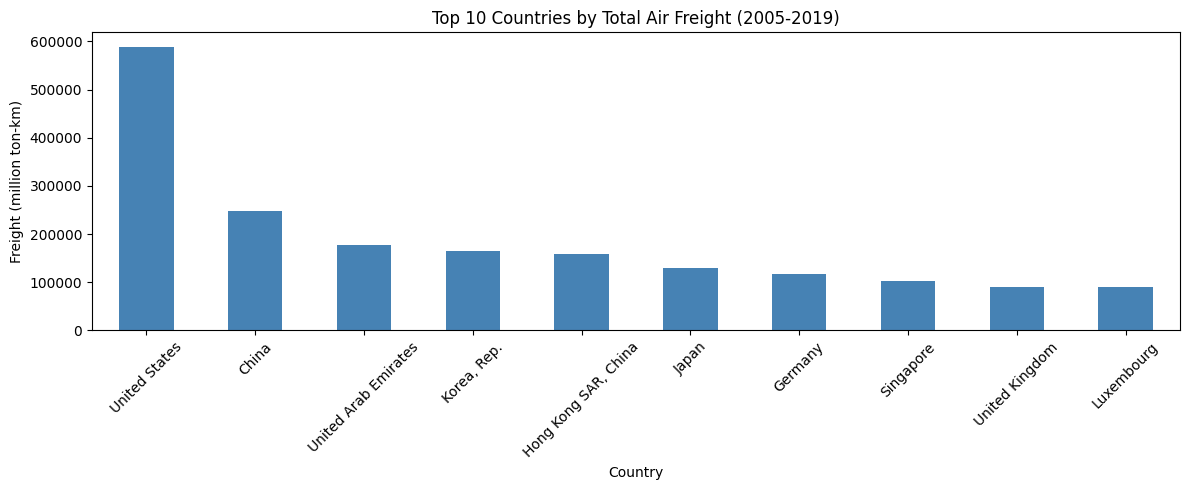

In [19]:
import matplotlib.pyplot as plt

top10.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Top 10 Countries by Total Air Freight (2005-2019)')
plt.xlabel('Country')
plt.ylabel('Freight (million ton-km)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

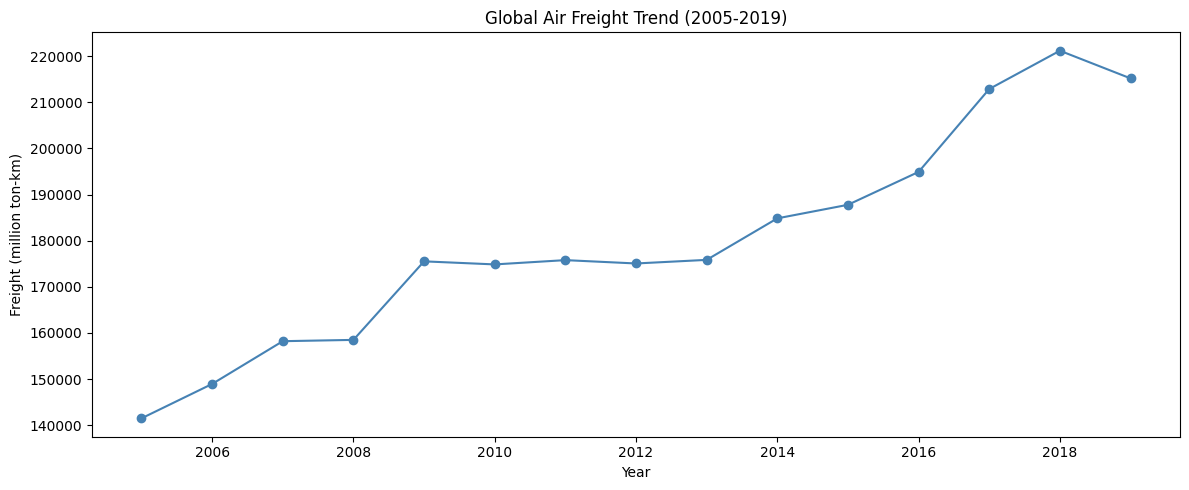

In [20]:
yearly = df_countries.groupby('year')['freight_mton_km'].sum()

yearly.plot(kind='line', figsize=(12, 5), marker='o', color='steelblue')
plt.title('Global Air Freight Trend (2005-2019)')
plt.xlabel('Year')
plt.ylabel('Freight (million ton-km)')
plt.tight_layout()
plt.show()

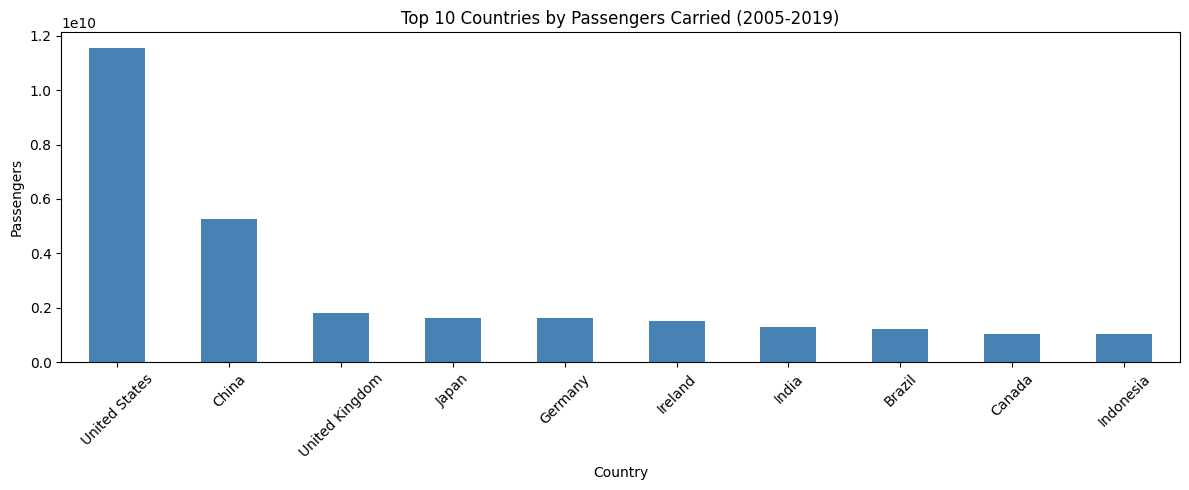

In [21]:
top10_pax = df_countries.groupby('country')['passengers'].sum().sort_values(ascending=False).head(10)

top10_pax.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Top 10 Countries by Passengers Carried (2005-2019)')
plt.xlabel('Country')
plt.ylabel('Passengers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

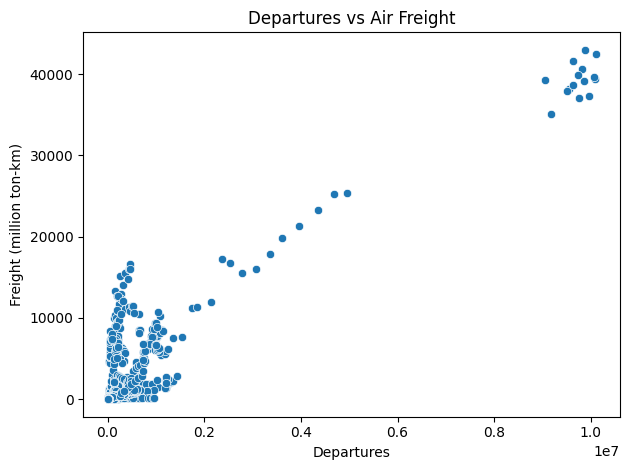

In [22]:
import seaborn as sns

sns.scatterplot(data=df_countries, x='departures', y='freight_mton_km')
plt.title('Departures vs Air Freight')
plt.xlabel('Departures')
plt.ylabel('Freight (million ton-km)')
plt.tight_layout()
plt.show()

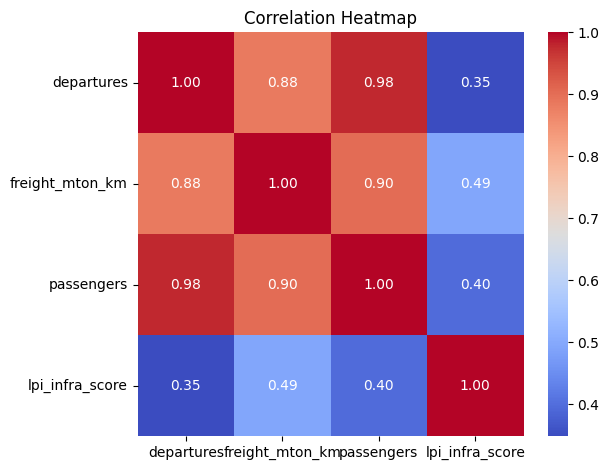

In [23]:
corr = df_countries[['departures', 'freight_mton_km', 'passengers', 'lpi_infra_score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

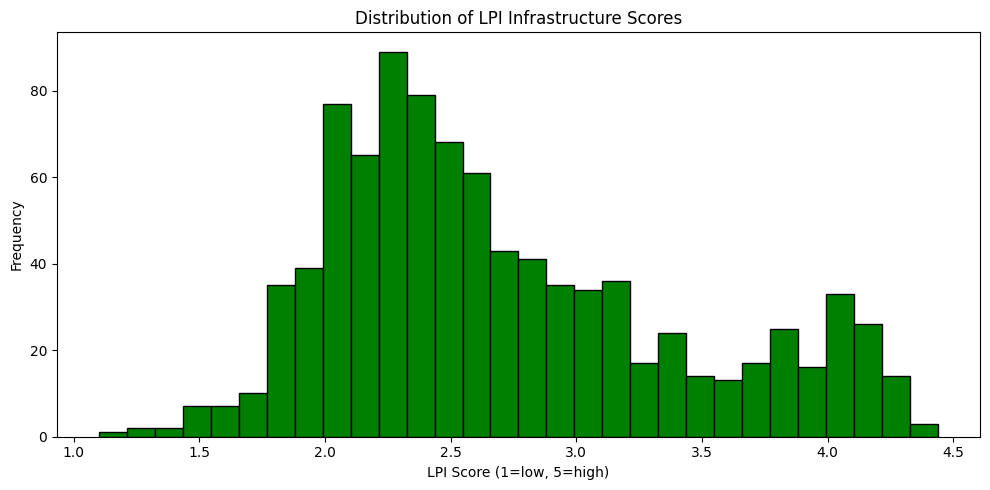

In [25]:
df_countries['lpi_infra_score'].dropna().plot(kind='hist', bins=30, figsize=(10, 5), color='green', edgecolor='black')
plt.title('Distribution of LPI Infrastructure Scores')
plt.xlabel('LPI Score (1=low, 5=high)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

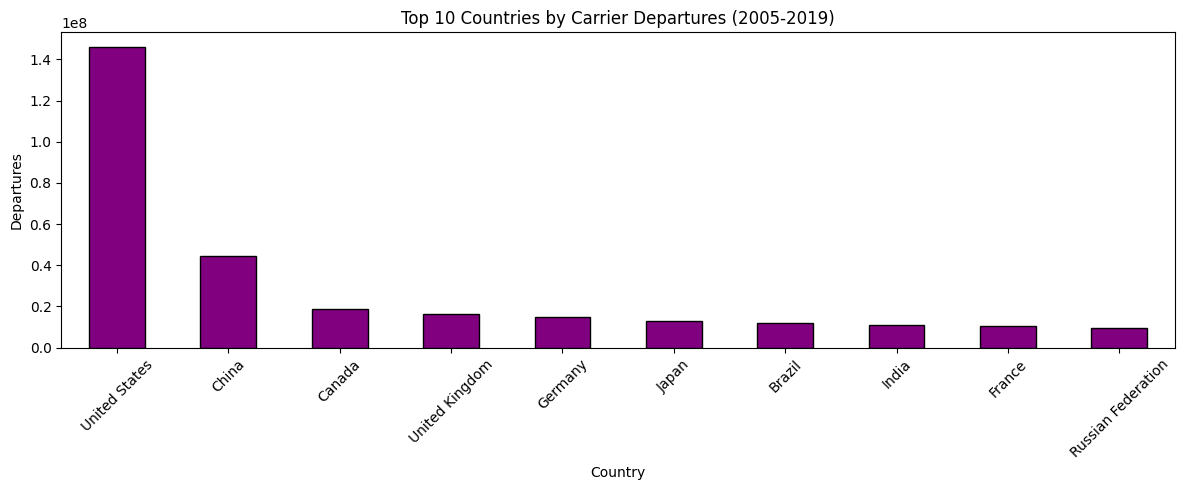

In [26]:
top10_dep = df_countries.groupby('country')['departures'].sum().sort_values(ascending=False).head(10)

top10_dep.plot(kind='bar', figsize=(12, 5), color='purple', edgecolor='black')
plt.title('Top 10 Countries by Carrier Departures (2005-2019)')
plt.xlabel('Country')
plt.ylabel('Departures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df_countries.to_csv("air_cargo_eda.csv", index=False)
print("Saved! Shape:", df_countries.shape)

Saved! Shape: (2397, 7)
